## IMPORTS

In [17]:
import torchimport torch.nn as nnimport torchvisionimport torchvision.transforms as transformsimport matplotlib.pyplot as pltimport numpy as npimport torch.optim as optimfrom tqdm import tqdmfrom sklearn.metrics import roc_curve, auc

## Q1: DATA

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


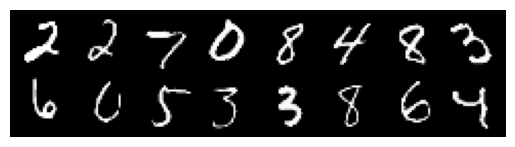

In [9]:
# Transformation pipeline to convert images to Tensors and normalize themtransform = transforms.Compose([    transforms.ToTensor(),    transforms.Normalize((0.5,), (0.5,))])# Load the MNIST training datasettrainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)# Load the MNIST test datasettestset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)# Get a single batch of imagesimages, labels = next(iter(trainloader))# Display a grid of the first 16 images from the batchimg_grid = torchvision.utils.make_grid(images[:16])npimg = img_grid.numpy()plt.imshow(np.transpose(npimg, (1, 2, 0)))plt.axis('off')plt.show()

## Q2: Auto-encoder

In [ ]:
# Define the size of the latent spacelatent_dims = 10class Encoder(nn.Module):    def __init__(self):        super(Encoder, self).__init__()        self.conv_layers = nn.Sequential(            # Input: 1 x 28 x 28            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> 16 x 14 x 14            nn.ReLU(True),            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> 32 x 7 x 7            nn.ReLU(True),            nn.Conv2d(32, 64, kernel_size=7) # -> 64 x 1 x 1        )    def forward(self, x):        x = self.conv_layers(x)        return xclass Decoder(nn.Module):    def __init__(self):        super(Decoder, self).__init__()        self.deconv_layers = nn.Sequential(            # Input: 64 x 1 x 1            nn.ConvTranspose2d(64, 32, kernel_size=7), # -> 32 x 7 x 7            nn.ReLU(True),            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 16 x 14 x 14            nn.ReLU(True),            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 1 x 28 x 28            nn.Tanh() # To scale output pixels to [-1, 1]        )    def forward(self, x):        x = self.deconv_layers(x)        return xclass Autoencoder(nn.Module):    def __init__(self):        super(Autoencoder, self).__init__()        self.encoder = Encoder()        self.decoder = Decoder()    def forward(self, x):        latent = self.encoder(x)        x_recon = self.decoder(latent)        return x_reconautoencoder = Autoencoder()

## Q3: 

In [ ]:
# the optimizer and the reconstruction loss function (L_con)optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)reconstruction_loss = nn.MSELoss()

Starting Autoencoder Training...


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [5/5]: 100%|██████████| 938/938 [01:35<00:00,  9.78it/s, loss=0.0095] 



Training Complete.
Displaying original and reconstructed images from the test set.


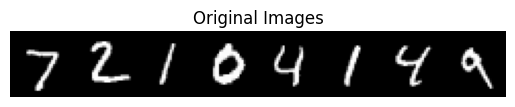

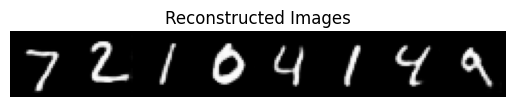

In [ ]:
num_epochs = 5print("Starting Autoencoder Training...")for epoch in range(num_epochs):    loop = tqdm(trainloader, leave=True)    for data in loop:        img, _ = data        recon = autoencoder(img)        loss = reconstruction_loss(recon, img)        optimizer.zero_grad()        loss.backward()        optimizer.step()        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")        loop.set_postfix(loss=loss.item())print("\nTraining Complete.")# --- Visualize reconstruction results ---test_images, _ = next(iter(testloader))with torch.no_grad():    reconstructed_images = autoencoder(test_images)def show_image_grid(imgs, title=""):    # Un-normalize for display    imgs = imgs / 2 + 0.5    grid = torchvision.utils.make_grid(imgs)    npgrid = grid.numpy()    plt.imshow(np.transpose(npgrid, (1, 2, 0)))    plt.title(title)    plt.axis('off')    plt.show()print("Displaying original and reconstructed images from the test set.")show_image_grid(test_images, "Original Images")show_image_grid(reconstructed_images, "Reconstructed Images")